# Bài tập thực hành 4

# Hồi quy bằng Mạng Nơ-ron Đa lớp (MLP): Dự đoán Giá Nhà

## Giới thiệu

Dự đoán giá nhà là một bài toán hồi quy phổ biến trong lĩnh vực học máy (Machine Learning). Mục tiêu của bài toán là ước lượng giá trị trung bình của các ngôi nhà dựa trên nhiều đặc trưng số mô tả các yếu tố về nhân khẩu học, môi trường và kinh tế.

Trong notebook này, một mô hình hồi quy sử dụng Mạng Nơ-ron Đa lớp (Multilayer Perceptron – MLP) được xây dựng để dự đoán giá nhà bằng cách sử dụng **bộ dữ liệu Boston Housing**. Sau đó, hiệu suất của mô hình MLP được so sánh với ba thuật toán hồi quy truyền thống gồm **Linear Regression, Decision Tree Regression và Random Forest Regression**.

Các mô hình được đánh giá bằng các chỉ số **Mean Squared Error (MSE)**, **Mean Absolute Error (MAE)** và **R-squared (R²)** nhằm xác định mô hình nào mang lại hiệu quả dự đoán giá nhà tốt nhất.

## Mục tiêu

Mục tiêu của bài thực hành này bao gồm:

- Tải và khám phá bộ dữ liệu **Boston Housing**.
- Thực hiện tiền xử lý dữ liệu và chuẩn hóa các đặc trưng.
- Xây dựng mô hình hồi quy sử dụng **Mạng Nơ-ron Đa lớp (Multilayer Perceptron – MLP)**.
- Huấn luyện và đánh giá hiệu suất của mô hình MLP.
- Dự đoán giá nhà trên tập dữ liệu kiểm tra.
- So sánh hiệu suất của mô hình MLP với các mô hình **Linear Regression, Decision Tree Regression và Random Forest Regression**.
- Phân tích hiệu quả dự đoán của các mô hình dựa trên các chỉ số **Mean Squared Error (MSE)**, **Mean Absolute Error (MAE)** và **R-squared (R²)**.

# 1. Import Necessary Libraries

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
print("TensorFlow Version :", tf.__version__)
print("Pandas Version     :", pd.__version__)
print("NumPy Version      :", np.__version__)

TensorFlow Version : 2.21.0
Pandas Version     : 2.3.3
NumPy Version      : 2.2.6


# 2. Load and Explore the Boston Housing Dataset

## Dataset Overview

Bộ dữ liệu **Boston Housing** là một bộ dữ liệu hồi quy nổi tiếng, thường được sử dụng để xây dựng và đánh giá các mô hình dự đoán giá nhà. Bộ dữ liệu gồm **506 mẫu** và **13 đặc trưng số**, mô tả nhiều đặc điểm khác nhau của các khu dân cư, chẳng hạn như tỷ lệ tội phạm, số lượng phòng trung bình, thuế bất động sản, mức độ thuận tiện trong việc tiếp cận các tuyến đường cao tốc và các yếu tố kinh tế – xã hội.

Biến mục tiêu của bộ dữ liệu là **MEDV** (*Median Value of Owner-Occupied Homes*), biểu thị **giá trị trung vị của các căn nhà do chủ sở hữu sinh sống**, được tính theo **đơn vị nghìn đô la Mỹ (USD)**.

Do hàm `load_boston()` đã bị loại bỏ khỏi các phiên bản mới của **Scikit-learn**, notebook này sử dụng bộ dữ liệu **Boston Housing** được tải từ **OpenML**, trong khi nội dung và cấu trúc của bộ dữ liệu vẫn được giữ nguyên.

**2.1 Load and Explore the Dataset**

In [3]:
# ==========================================
# Load Boston Housing Dataset
# ==========================================

boston = fetch_openml(
    name="boston",
    version=1,
    as_frame=True
)

df = boston.frame

In [4]:
# Display the first five rows

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## Khám phá bộ dữ liệu

Trước khi thực hiện các bước tiền xử lý, việc khám phá bộ dữ liệu là rất cần thiết nhằm hiểu rõ cấu trúc và đặc điểm của dữ liệu. Nội dung khám phá bao gồm kiểm tra cấu trúc của bộ dữ liệu, kiểu dữ liệu của các thuộc tính, các thống kê mô tả cơ bản và kiểm tra sự tồn tại của các giá trị thiếu (missing values). Quá trình này giúp đánh giá chất lượng dữ liệu và làm cơ sở cho các bước tiền xử lý tiếp theo.

In [5]:
# Display dataset dimensions

print("Dataset Shape:", df.shape)

Dataset Shape: (506, 14)


In [6]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB


In [7]:
# Display statistical summary

df.describe()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,396.900000,37.970000,50.000000


### Nhận xét

Bảng thống kê mô tả cung cấp các thông tin quan trọng như giá trị trung bình (Mean), độ lệch chuẩn (Standard Deviation), giá trị nhỏ nhất (Minimum), giá trị lớn nhất (Maximum) và các giá trị tứ phân vị (Quartiles) của từng đặc trưng. Những thông tin này giúp hiểu rõ hơn về phân bố của dữ liệu, phạm vi biến thiên của các đặc trưng và hỗ trợ quá trình tiền xử lý cũng như xây dựng mô hình.

In [8]:
# Check missing values

df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

**2.2 Data Preprocessing**


In [9]:
# ==========================================
# Separate Features and Target Variable
# ==========================================

X = df.drop("MEDV", axis=1)
y = df["MEDV"]

print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape :", y.shape)

Feature Matrix Shape: (506, 13)
Target Vector Shape : (506,)


In [10]:
# Split the Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (404, 13)
Testing Set  : (102, 13)


In [11]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
print("Training Data Shape:", X_train_scaled.shape)
print("Testing Data Shape :", X_test_scaled.shape)

Training Data Shape: (404, 13)
Testing Data Shape : (102, 13)


### Nhận xét

Các đặc trưng đầu vào đã được chuẩn hóa bằng **StandardScaler**. Việc chuẩn hóa giúp đưa tất cả các biến về cùng một thang đo, từ đó cải thiện tính ổn định trong quá trình huấn luyện và tăng tốc độ hội tụ của mô hình **Mạng Nơ-ron Đa lớp (MLP)**. Đồng thời, quá trình này cũng góp phần nâng cao hiệu quả và độ chính xác của mô hình trong quá trình dự đoán.

In [13]:
# Display the first five rows of the standardized training data

pd.DataFrame(
    X_train_scaled,
    columns=X.columns
).head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,1.287702,-0.500320,1.033237,-0.278089,0.489252,-1.428069,1.028015,-0.802173,1.706891,1.578434,0.845343,-0.074337,1.753505
1,-0.336384,-0.500320,-0.413160,-0.278089,-0.157233,-0.680087,-0.431199,0.324349,-0.624360,-0.584648,1.204741,0.430184,-0.561474
2,-0.403253,1.013271,-0.715218,-0.278089,-1.008723,-0.402063,-1.618599,1.330697,-0.974048,-0.602724,-0.637176,0.065297,-0.651595
3,0.388230,-0.500320,1.033237,-0.278089,0.489252,-0.300450,0.591681,-0.839240,1.706891,1.578434,0.845343,-3.868193,1.525387
4,-0.325282,-0.500320,-0.413160,-0.278089,-0.157233,-0.831094,0.033747,-0.005494,-0.624360,-0.584648,1.204741,0.379119,-0.165787




## 3. Xây dựng mô hình Mạng Nơ-ron Đa lớp (MLP)

Mạng Nơ-ron Đa lớp (**Multilayer Perceptron – MLP**) là một loại mạng nơ-ron nhân tạo gồm nhiều lớp kết nối đầy đủ (**Dense layers**), trong đó mỗi nơ-ron của một lớp được kết nối với tất cả các nơ-ron của lớp kế tiếp.

Trong bài thực hành này, kiến trúc của mô hình bao gồm:

- Một **lớp đầu vào (Input Layer)** với **13 đặc trưng đầu vào**.
- Một **lớp ẩn thứ nhất (Hidden Layer)** gồm **32 nơ-ron**, sử dụng hàm kích hoạt **ReLU (Rectified Linear Unit)**.
- Một **lớp ẩn thứ hai (Hidden Layer)** gồm **16 nơ-ron**, cũng sử dụng hàm kích hoạt **ReLU**.
- Một **lớp đầu ra (Output Layer)** gồm **1 nơ-ron** với **hàm kích hoạt tuyến tính (Linear Activation Function)** để dự đoán giá nhà.

Mô hình được biên dịch (**compile**) bằng bộ tối ưu hóa **Adam (Adaptive Moment Estimation)** và sử dụng **Mean Squared Error (MSE)** làm hàm mất mát (**Loss Function**). Bên cạnh đó, **Mean Absolute Error (MAE)** được sử dụng làm chỉ số đánh giá nhằm theo dõi hiệu suất của mô hình trong suốt quá trình huấn luyện.

In [14]:

# Build the MLP Model

model = Sequential()

# Input layer + Hidden layer 1
model.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))

# Hidden layer 2
model.add(Dense(16, activation='relu'))

# Output layer
model.add(Dense(1, activation='linear'))

c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

### Nhận xét

Mô hình **Mạng Nơ-ron Đa lớp (Multilayer Perceptron – MLP)** đã được xây dựng thành công với **hai lớp ẩn** và **một lớp đầu ra**.

- **Lớp đầu vào (Input Layer):** gồm **13 đặc trưng đầu vào**.
- **Lớp ẩn thứ nhất (Hidden Layer 1):** gồm **32 nơ-ron**, sử dụng hàm kích hoạt **ReLU**.
- **Lớp ẩn thứ hai (Hidden Layer 2):** gồm **16 nơ-ron**, sử dụng hàm kích hoạt **ReLU**.
- **Lớp đầu ra (Output Layer):** gồm **1 nơ-ron**, sử dụng **hàm kích hoạt tuyến tính (Linear Activation Function)** để dự đoán giá nhà.

Mô hình có tổng cộng **993 tham số có thể huấn luyện (trainable parameters)**. Các tham số này sẽ được cập nhật trong quá trình huấn luyện nhằm tối ưu hóa khả năng dự đoán của mô hình. Với kiến trúc gồm hai lớp ẩn và số lượng tham số không quá lớn, mô hình phù hợp để giải quyết bài toán hồi quy trên bộ dữ liệu **Boston Housing**, vốn có kích thước tương đối nhỏ.

In [16]:
# Compile the Model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# 4. Train the MLP Model

## Model Training.

In [17]:

# Train the MLP Model

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    verbose=1
)

Epoch 1/100


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 572.3596 - mae: 22.0803 - val_loss: 486.8741 - val_mae: 20.4469
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 547.6080 - mae: 21.5356 - val_loss: 462.6601 - val_mae: 19.8940
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 519.5298 - mae: 20.9013 - val_loss: 432.9355 - val_mae: 19.1991
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 485.4853 - mae: 20.1010 - val_loss: 396.3213 - val_mae: 18.3055
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 442.8763 - mae: 19.0600 - val_loss: 352.5701 - val_mae: 17.1578
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 393.2706 - mae: 17.7458 - val_loss: 301.1732 - val_mae: 15.7139
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 336.3063 - mae: 16.0678 - val_loss: 244.8613 - val_mae: 13.9631
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 273.9795 - mae: 14.1150 - val_loss: 188.0747 - val_mae: 12.0313
Epoch 9/100
13/13 ━━

### Nhận xét

Quá trình huấn luyện mô hình đã được hoàn thành thành công sau **100 epoch**.

Trong suốt quá trình huấn luyện, cả **Training Loss** và **Validation Loss** đều giảm đáng kể, cho thấy mô hình đã học được mối quan hệ giữa các đặc trưng đầu vào và giá nhà một cách hiệu quả.

Đồng thời, các chỉ số **Mean Squared Error (MSE)** và **Mean Absolute Error (MAE)** ở cuối quá trình huấn luyện thấp hơn nhiều so với thời điểm ban đầu. Điều này cho thấy mô hình đã hội tụ, đạt được hiệu suất dự đoán tốt và không xuất hiện dấu hiệu rõ ràng của hiện tượng **quá khớp (overfitting)**.

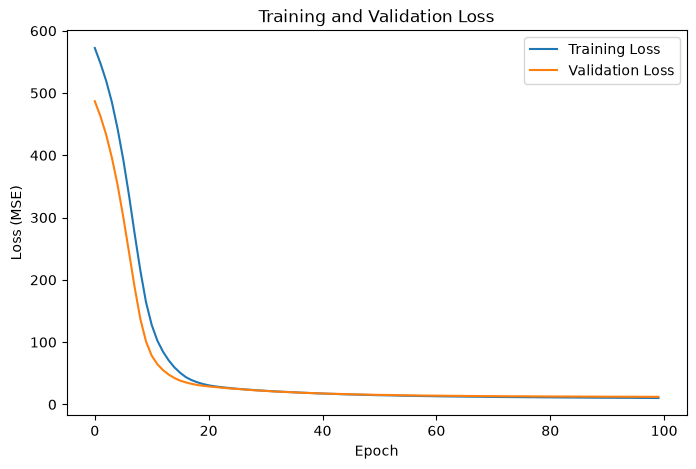

In [18]:
# Plot Training and Validation Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

plt.show()

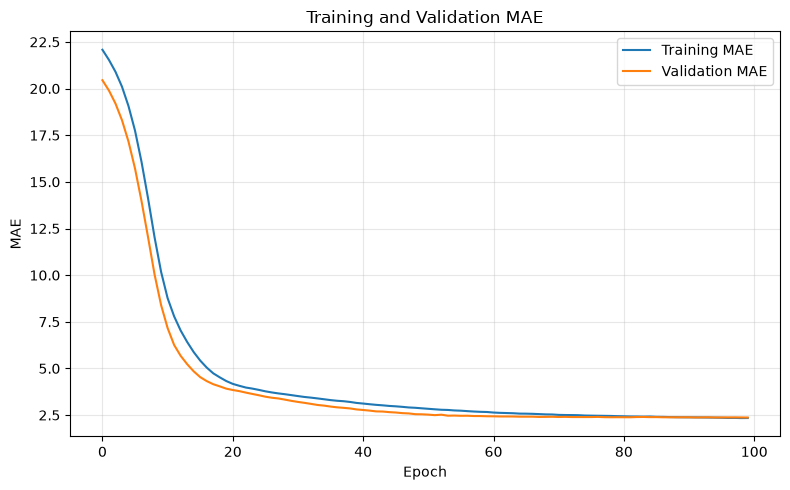

In [19]:
plt.figure(figsize=(8,5))

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.title('Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Nhận xét

Các chỉ số **Training MAE** và **Validation MAE** giảm nhanh trong những epoch đầu tiên, cho thấy mô hình nhanh chóng học được mối quan hệ giữa các đặc trưng đầu vào và biến mục tiêu.

Sau khoảng **20 epoch**, cả hai đường MAE dần ổn định và hội tụ về mức thấp, khoảng **2.3–2.5**. Khoảng cách nhỏ giữa đường **Training MAE** và **Validation MAE** cho thấy mô hình có khả năng tổng quát hóa tốt trên dữ liệu chưa được sử dụng trong quá trình huấn luyện và không xuất hiện dấu hiệu đáng kể của hiện tượng **quá khớp (overfitting)**.

Nhìn chung, mô hình **Mạng Nơ-ron Đa lớp (MLP)** đạt quá trình huấn luyện ổn định và mang lại độ chính xác dự đoán tốt trên tập dữ liệu kiểm tra.

# 5. Evaluate the MLP Model

## Đánh giá mô hình

Sau khi hoàn thành quá trình huấn luyện, mô hình **Mạng Nơ-ron Đa lớp (MLP)** được đánh giá trên **tập dữ liệu kiểm tra (testing dataset)**. Hiệu suất của mô hình được đánh giá thông qua các chỉ số **Mean Squared Error (MSE)**, **Mean Absolute Error (MAE)** và **R-squared (R²)**.

Tiếp theo, mô hình đã huấn luyện được sử dụng để dự đoán giá nhà trên tập dữ liệu kiểm tra. Cuối cùng, các giá trị dự đoán được so sánh với giá trị thực tế nhằm đánh giá mức độ chính xác và hiệu quả dự đoán của mô hình.

In [20]:
# Evaluate the MLP Model
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)

print("Test MSE :", test_loss)
print("Test MAE :", test_mae)

Test MSE : 12.199297904968262
Test MAE : 2.369663715362549


In [21]:
# Make Predictions 

y_pred = model.predict(X_test_scaled)

# Convert predictions to 1D array
y_pred = y_pred.flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [22]:
# Calculate Performance Metrics

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R²): {r2:.4f}")

Mean Squared Error (MSE): 12.1993
Mean Absolute Error (MAE): 2.3697
R-squared (R²): 0.8336


In [23]:
# Display the first 10 predictions

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,23.6,27.255041
1,32.4,34.147038
2,13.6,18.473206
3,22.8,26.461020
4,16.1,15.849457
5,20.0,20.004721
6,17.8,16.207335
7,14.0,13.885483
8,19.6,25.700193
9,16.8,16.457876


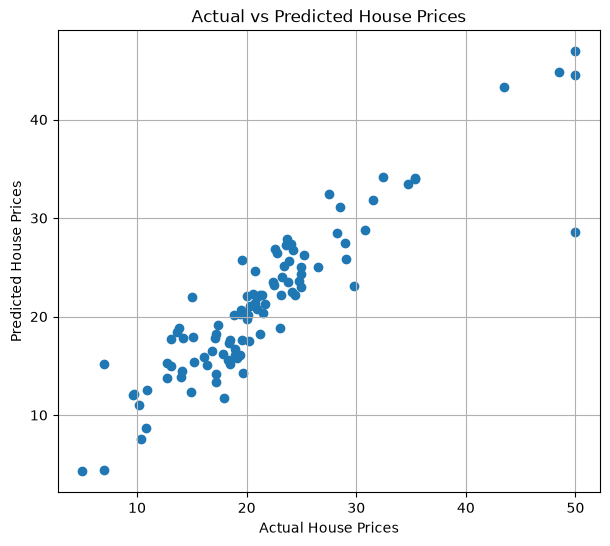

In [24]:
# Actual vs Predicted Prices

plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.grid(True)

plt.show()

### Nhận xét

Biểu đồ phân tán (Scatter Plot) thể hiện mối quan hệ giữa **giá nhà thực tế** và **giá nhà dự đoán** do mô hình **Mạng Nơ-ron Đa lớp (MLP)** tạo ra.

Nếu các giá trị dự đoán gần với giá trị thực tế, các điểm dữ liệu sẽ phân bố gần **đường chéo tưởng tượng** (đường biểu diễn trường hợp dự đoán hoàn hảo). Điều này cho thấy mô hình có khả năng dự đoán chính xác.

Bên cạnh đó, các chỉ số **Mean Squared Error (MSE)**, **Mean Absolute Error (MAE)** và **R-squared (R²)** cung cấp đánh giá định lượng về độ chính xác cũng như khả năng tổng quát hóa của mô hình. Giá trị **MSE** và **MAE** càng thấp, cùng với **R²** càng cao, chứng tỏ hiệu suất dự đoán của mô hình càng tốt.

# 6. Performance Comparison with Other Regression Models

## Model Comparison

Để đánh giá hiệu quả của mô hình **Mạng Nơ-ron Đa lớp (Multilayer Perceptron – MLP)**, hiệu suất của mô hình được so sánh với ba thuật toán hồi quy truyền thống, bao gồm:

- **Linear Regression (Hồi quy tuyến tính)**
- **Decision Tree Regression (Hồi quy cây quyết định)**
- **Random Forest Regression (Hồi quy rừng ngẫu nhiên)**

Mỗi mô hình được đánh giá dựa trên các chỉ số sau:

- **Mean Squared Error (MSE)**
- **R-squared (R²)**

Kết quả đánh giá của các mô hình được tổng hợp trong một bảng so sánh để thuận tiện cho việc phân tích và đánh giá hiệu suất dự đoán của từng mô hình.

In [25]:
# Linear Regression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MSE :", lr_mse)
print("R²  :", lr_r2)

Linear Regression
MSE : 24.291119474973517
R²  : 0.668759493535632


In [26]:
 # Decision Tree Regression

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Regression")
print("MSE :", dt_mse)
print("R²  :", dt_r2)

Decision Tree Regression
MSE : 17.81558823529412
R²  : 0.7570616506127126


In [27]:
# Random Forest Regression

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Regression")
print("MSE :", rf_mse)
print("R²  :", rf_r2)

Random Forest Regression
MSE : 7.88021732352941
R²  : 0.8925431501835708


In [28]:
# Performance Comparison

comparison = pd.DataFrame({
    "Model": [
        "MLP",
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MSE": [
        mse,
        lr_mse,
        dt_mse,
        rf_mse
    ],
    "R² Score": [
        r2,
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

comparison

,Model,MSE,R² Score
0,MLP,12.199297,0.833647
1,Linear Regression,24.291119,0.668759
2,Decision Tree,17.815588,0.757062
3,Random Forest,7.880217,0.892543


In [29]:
comparison.sort_values(by="MSE")

,Model,MSE,R² Score
3,Random Forest,7.880217,0.892543
0,MLP,12.199297,0.833647
2,Decision Tree,17.815588,0.757062
1,Linear Regression,24.291119,0.668759


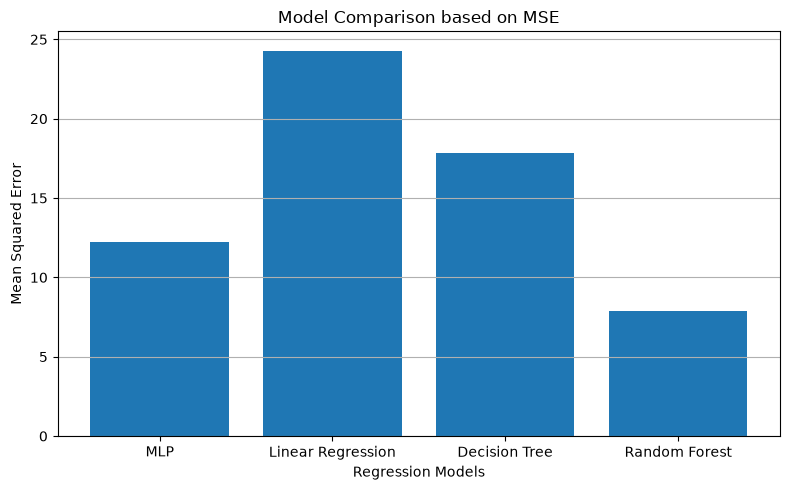

In [30]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["MSE"])

plt.title("Model Comparison based on MSE")
plt.xlabel("Regression Models")
plt.ylabel("Mean Squared Error")

plt.grid(axis="y")

plt.tight_layout()
plt.show()

### Nhận xét

Biểu đồ so sánh **Mean Squared Error (MSE)** cho thấy sự khác biệt về sai số dự đoán giữa các mô hình hồi quy.

Kết quả cho thấy **Random Forest Regression** đạt giá trị **MSE thấp nhất**, chứng tỏ mô hình này có sai số dự đoán nhỏ nhất và mang lại hiệu suất tốt nhất trên bộ dữ liệu Boston Housing.

**Decision Tree Regression** có giá trị MSE thấp hơn mô hình MLP, cho thấy mô hình này dự đoán khá chính xác. Tuy nhiên, **MLP** vẫn đạt kết quả tốt với MSE tương đối thấp và vượt trội hơn **Linear Regression**.

Trong khi đó, **Linear Regression** có giá trị MSE cao nhất, cho thấy mô hình này có sai số dự đoán lớn nhất và hiệu quả thấp hơn so với các mô hình còn lại.

Nhìn chung, biểu đồ MSE cho thấy **Random Forest Regression** là mô hình có hiệu suất dự đoán tốt nhất, tiếp theo là **Decision Tree Regression**, **MLP** và cuối cùng là **Linear Regression**.

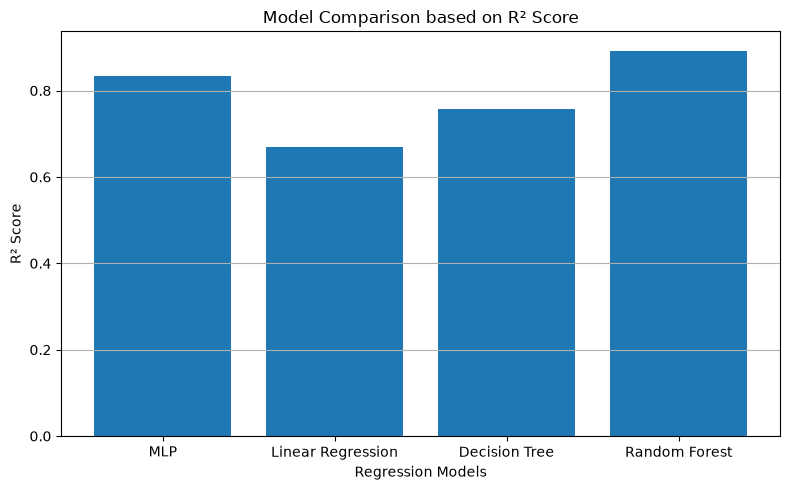

In [31]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["R² Score"])

plt.title("Model Comparison based on R² Score")
plt.xlabel("Regression Models")
plt.ylabel("R² Score")

plt.grid(axis="y")

plt.tight_layout()
plt.show()

### Nhận xét

Biểu đồ so sánh **R-squared (R²)** thể hiện khả năng giải thích sự biến thiên của giá nhà của từng mô hình hồi quy.

Kết quả cho thấy **Random Forest Regression** đạt giá trị **R² cao nhất**, chứng tỏ mô hình này có khả năng giải thích dữ liệu tốt nhất và mang lại độ chính xác dự đoán cao nhất.

**MLP** đạt giá trị **R² cao thứ hai**, cho thấy mô hình có khả năng học tốt mối quan hệ giữa các đặc trưng đầu vào và giá nhà, đồng thời đạt hiệu suất dự đoán cao hơn **Decision Tree Regression** và **Linear Regression**.

**Decision Tree Regression** có giá trị **R²** ở mức khá nhưng vẫn thấp hơn MLP, cho thấy khả năng tổng quát hóa của mô hình chưa tốt bằng MLP.

Trong khi đó, **Linear Regression** có giá trị **R² thấp nhất**, cho thấy mô hình chỉ giải thích được một phần nhỏ sự biến thiên của dữ liệu và có hiệu quả dự đoán thấp nhất trong bốn mô hình.

Nhìn chung, biểu đồ **R²** cho thấy **Random Forest Regression** là mô hình có khả năng dự đoán tốt nhất, tiếp theo là **MLP**, **Decision Tree Regression** và cuối cùng là **Linear Regression**.

## Comparison

Dựa trên hai chỉ số đánh giá là **Mean Squared Error (MSE)** và **R-squared (R²)**, có thể thấy sự khác biệt rõ ràng về hiệu suất của bốn mô hình hồi quy.

**Random Forest Regression** đạt kết quả tốt nhất khi có **MSE thấp nhất** và **R² cao nhất**, cho thấy mô hình có sai số dự đoán nhỏ nhất và khả năng giải thích dữ liệu tốt nhất. Điều này chứng tỏ Random Forest là mô hình phù hợp nhất cho bài toán dự đoán giá nhà trên bộ dữ liệu Boston Housing.

**Multilayer Perceptron (MLP)** đạt hiệu suất khá cao với **R² đứng thứ hai**, cho thấy mô hình có khả năng học tốt các mối quan hệ phi tuyến giữa các đặc trưng đầu vào và giá nhà. Mặc dù giá trị MSE của MLP cao hơn Decision Tree Regression, mô hình vẫn có khả năng tổng quát hóa tốt hơn thông qua chỉ số R².

**Decision Tree Regression** đạt **MSE thấp hơn MLP**, tuy nhiên **R² thấp hơn**, cho thấy mô hình dự đoán tốt đối với nhiều mẫu nhưng khả năng giải thích toàn bộ sự biến thiên của dữ liệu chưa bằng MLP. Điều này có thể xuất phát từ xu hướng overfitting của cây quyết định khi chỉ sử dụng một cây duy nhất.

**Linear Regression** có **MSE cao nhất** và **R² thấp nhất**, cho thấy đây là mô hình có hiệu suất thấp nhất trong bốn mô hình được so sánh. Nguyên nhân là do mô hình chỉ giả định mối quan hệ tuyến tính giữa các đặc trưng và giá nhà, trong khi bộ dữ liệu Boston Housing chứa nhiều mối quan hệ phi tuyến.

Nhìn chung, xét trên cả hai chỉ số MSE và R², **Random Forest Regression** là mô hình có hiệu suất tốt nhất, tiếp theo là **MLP**, **Decision Tree Regression** và cuối cùng là **Linear Regression**.

# 7. Analysis of Results

## 7.1 Phân tích quá trình huấn luyện

Trong quá trình huấn luyện, cả **Training Loss** và **Validation Loss** đều giảm nhanh trong những epoch đầu tiên, sau đó giảm chậm và dần ổn định. Điều này cho thấy mô hình Mạng Nơ-ron Đa lớp (MLP) đã học được mối quan hệ giữa các đặc trưng đầu vào và giá nhà một cách hiệu quả.

Tương tự, các chỉ số **Training MAE** và **Validation MAE** cũng giảm liên tục trong suốt quá trình huấn luyện và hội tụ về mức thấp. Khoảng cách giữa hai đường Training và Validation không lớn, chứng tỏ mô hình có khả năng tổng quát hóa tốt trên dữ liệu chưa được sử dụng trong quá trình huấn luyện.

Dựa trên các đường cong học (Learning Curves), mô hình không xuất hiện dấu hiệu rõ ràng của hiện tượng **quá khớp (overfitting)** hoặc **thiếu khớp (underfitting)**. Nhìn chung, quá trình huấn luyện diễn ra ổn định và mô hình đã hội tụ thành công.

## 7.2 Phân tích kết quả của mô hình MLP

Sau khi hoàn thành quá trình huấn luyện, mô hình MLP đạt được giá trị **Mean Squared Error (MSE)** và **Mean Absolute Error (MAE)** tương đối thấp, cho thấy sai số giữa giá trị dự đoán và giá trị thực tế không lớn.

Chỉ số **R-squared (R²)** đạt giá trị khá cao, chứng tỏ mô hình có khả năng giải thích phần lớn sự biến thiên của giá nhà trong bộ dữ liệu Boston Housing.

Bên cạnh đó, biểu đồ **Actual vs. Predicted** cho thấy phần lớn các điểm dữ liệu phân bố gần đường chéo, chứng tỏ giá trị dự đoán khá sát với giá trị thực tế. Tuy nhiên, vẫn còn một số điểm phân tán, đặc biệt ở các mức giá cao, cho thấy mô hình vẫn tồn tại sai số đối với một số mẫu dữ liệu.

Nhìn chung, mô hình MLP đạt độ chính xác dự đoán tốt và có khả năng giải quyết hiệu quả bài toán dự đoán giá nhà.

## 7.3 So sánh với các mô hình hồi quy khác

Kết quả thực nghiệm cho thấy có sự khác biệt rõ rệt về hiệu suất giữa bốn mô hình hồi quy được sử dụng trong bài thực hành.

**Random Forest Regression** đạt kết quả tốt nhất khi có **MSE thấp nhất** và **R² cao nhất**, chứng tỏ đây là mô hình có độ chính xác dự đoán và khả năng tổng quát hóa cao nhất.

Đối với chỉ số **MSE**, **Decision Tree Regression** đạt kết quả tốt hơn mô hình MLP. Tuy nhiên, xét theo chỉ số **R²**, **MLP** lại cao hơn Decision Tree Regression, cho thấy MLP giải thích được sự biến thiên của dữ liệu tốt hơn mặc dù vẫn còn một số sai số lớn làm tăng giá trị MSE.

Trong khi đó, **Linear Regression** có **MSE cao nhất** và **R² thấp nhất**, cho thấy đây là mô hình có hiệu suất thấp nhất đối với bộ dữ liệu Boston Housing.

Nhìn chung, **Random Forest Regression** là mô hình có hiệu suất tốt nhất, tiếp theo là **MLP**, **Decision Tree Regression** và cuối cùng là **Linear Regression**.

## 7.4 Giải thích kết quả

Random Forest Regression đạt kết quả tốt nhất vì đây là mô hình học tập theo phương pháp **Ensemble Learning**, kết hợp nhiều cây quyết định để giảm phương sai, tăng khả năng tổng quát hóa và học tốt các mối quan hệ phi tuyến trong dữ liệu.

Mặc dù mô hình MLP cũng có khả năng học các mối quan hệ phi tuyến, nhưng kết quả vẫn chưa vượt qua Random Forest. Một nguyên nhân là bộ dữ liệu Boston Housing chỉ gồm **506 mẫu**, tương đối nhỏ đối với việc huấn luyện mạng nơ-ron. Trong khi đó, Random Forest thường hoạt động rất hiệu quả trên các bộ dữ liệu có kích thước nhỏ và trung bình.

Decision Tree Regression đạt kết quả khá tốt nhưng chỉ sử dụng một cây quyết định nên dễ xảy ra hiện tượng quá khớp, dẫn đến khả năng tổng quát hóa chưa bằng Random Forest.

Linear Regression cho kết quả thấp nhất vì mô hình chỉ giả định mối quan hệ tuyến tính giữa các đặc trưng đầu vào và giá nhà. Trong khi đó, bộ dữ liệu Boston Housing chứa nhiều mối quan hệ phi tuyến nên mô hình không thể biểu diễn đầy đủ các đặc điểm của dữ liệu.

## 7.5 Đánh giá tổng quát

Qua toàn bộ quá trình thực nghiệm, mô hình MLP cho thấy khả năng dự đoán tốt với sai số tương đối thấp và khả năng tổng quát hóa cao. Quá trình huấn luyện diễn ra ổn định, không xuất hiện dấu hiệu rõ ràng của hiện tượng overfitting hay underfitting.

Tuy nhiên, khi so sánh với các mô hình hồi quy khác, **Random Forest Regression** vẫn là mô hình có hiệu suất tốt nhất dựa trên cả hai chỉ số **MSE** và **R²**. Mô hình MLP vẫn là một lựa chọn hiệu quả, vượt trội hơn **Linear Regression** và đạt **R²** cao hơn **Decision Tree Regression**.

Nhìn chung, đối với bài toán dự đoán giá nhà trên bộ dữ liệu **Boston Housing**, **Random Forest Regression** là mô hình phù hợp nhất. Trong khi đó, mô hình **MLP** vẫn thể hiện hiệu quả cao và khẳng định khả năng ứng dụng của mạng nơ-ron trong các bài toán hồi quy.

# 8. Kết luận

Trong bài thực hành này, mô hình **Mạng Nơ-ron Đa lớp (Multilayer Perceptron – MLP)** đã được xây dựng để giải quyết bài toán dự đoán giá nhà trên bộ dữ liệu **Boston Housing**. Quá trình thực hiện bao gồm các bước tiền xử lý dữ liệu, chuẩn hóa các đặc trưng bằng **StandardScaler**, xây dựng và huấn luyện mô hình MLP, đánh giá hiệu suất dựa trên các chỉ số **Mean Squared Error (MSE)**, **Mean Absolute Error (MAE)** và **R-squared (R²)**, đồng thời trực quan hóa kết quả dự đoán.

Kết quả thực nghiệm cho thấy mô hình MLP có khả năng dự đoán giá nhà khá chính xác với sai số tương đối thấp và khả năng tổng quát hóa tốt trên tập dữ liệu kiểm tra. Quá trình huấn luyện diễn ra ổn định, các giá trị Loss và MAE giảm dần theo số epoch, cho thấy mô hình đã hội tụ và không xuất hiện dấu hiệu rõ ràng của hiện tượng overfitting.

Bên cạnh đó, hiệu suất của mô hình MLP đã được so sánh với ba thuật toán hồi quy truyền thống gồm **Linear Regression**, **Decision Tree Regression** và **Random Forest Regression**. Kết quả cho thấy **Random Forest Regression** đạt hiệu suất cao nhất với giá trị **MSE thấp nhất** và **R² cao nhất**. Mặc dù chưa vượt qua Random Forest, mô hình MLP vẫn đạt kết quả tốt, vượt trội hơn Linear Regression và đạt giá trị R² cao hơn Decision Tree Regression.

Qua bài thực hành có thể thấy rằng việc lựa chọn mô hình phù hợp đóng vai trò quan trọng trong bài toán hồi quy. Đối với bộ dữ liệu **Boston Housing**, **Random Forest Regression** là mô hình mang lại hiệu quả dự đoán tốt nhất. Tuy nhiên, **Mạng Nơ-ron Đa lớp (MLP)** vẫn là một phương pháp hiệu quả, đặc biệt đối với các bài toán có dữ liệu lớn và các mối quan hệ phi tuyến phức tạp. Trong tương lai, hiệu suất của mô hình MLP có thể được cải thiện bằng cách điều chỉnh các siêu tham số, thay đổi kiến trúc mạng hoặc sử dụng các bộ dữ liệu có quy mô lớn hơn.